# Capstone Project — Network Intrusion Detection System (IDS)
**Course 01 | Guided Analytical Workflow**

Dataset modeled after CICIDS 2017 (Canadian Institute for Cybersecurity)

---

In [191]:
%pip install matplotlib seaborn scikit-learn --quiet

Note: you may need to restart the kernel to use updated packages.


## Section 1 — Problem Understanding

**Analytical Goal:**  
Build a machine learning classifier that can distinguish benign network traffic from five categories of cyberattacks: DDoS, Port Scan, Brute Force, Botnet, and Web Attack.

**Target Variable:**  
`Label` — a categorical column with 6 classes: `BENIGN`, `DDoS`, `PortScan`, `BruteForce`, `Botnet`, `WebAttack`.

**Real-World Relevance:**  
Network intrusion detection is a core component of enterprise cybersecurity. Automated, ML-based IDS can identify threats in real-time, reducing response time and minimizing damage from attacks.

In [192]:
# Imports
import subprocess, sys

# Ensure packages are installed in this kernel
subprocess.run([sys.executable, "-m", "pip", "install", "matplotlib", "seaborn", "scikit-learn", "-q"], check=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Section 2 — Data Exploration

In [193]:
# Load dataset
DATA_PATH = Path('capstone_network_ids_dataset.csv')
df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
df.head()

Shape: (10100, 31)


,Flow Duration,Total Fwd Packets,Total Bwd Packets,Total Length Fwd Pkts,Total Length Bwd Pkts,Fwd Pkt Len Mean,Bwd Pkt Len Mean,Flow Bytes/s,Flow Pkts/s,Flow IAT Mean,...,Pkt Len Min,Pkt Len Max,Pkt Len Mean,Pkt Len Std,FIN Flag Count,SYN Flag Count,RST Flag Count,ACK Flag Count,Down/Up Ratio,Label
0,36301.380473,13.0,20.0,0.000000,4349.440272,46.842663,97.432052,8.210993e+04,660.260542,133.431570,...,8.639780,823.788926,430.081637,138.876034,1.0,2.0,1.0,2.0,0.700605,BENIGN
1,7611.800741,87.0,NaN,16574.697802,113.425120,39.639702,0.000000,1.029946e+06,31242.710358,37.909489,...,20.912502,40.000000,40.952847,14.403462,0.0,1.0,0.0,1.0,0.013925,DDoS
2,102294.616705,NaN,6.0,3026.868662,1372.745253,135.934625,139.835171,4.439674e+04,761.034078,0.000000,...,34.228981,440.745125,249.671979,NaN,0.0,2.0,1.0,2.0,0.791692,BENIGN
3,8800.297398,190.0,1.0,8815.010611,0.000000,53.813770,40.769452,1.022717e+06,24578.268998,41.383273,...,26.302723,66.959707,59.606923,8.211750,0.0,1.0,1.0,1.0,0.033461,DDoS
4,97098.849830,6.0,8.0,0.000000,4424.532462,181.831850,NaN,5.243199e+04,NaN,16514.945909,...,29.732970,683.586966,294.594842,99.439528,1.0,1.0,0.0,4.0,1.275917,BENIGN


In [194]:
# Dataset structure and feature types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Flow Duration          9682 non-null   float64
 1   Total Fwd Packets      9714 non-null   float64
 2   Total Bwd Packets      9706 non-null   float64
 3   Total Length Fwd Pkts  9733 non-null   float64
 4   Total Length Bwd Pkts  9708 non-null   float64
 5   Fwd Pkt Len Mean       9714 non-null   float64
 6   Bwd Pkt Len Mean       9706 non-null   float64
 7   Flow Bytes/s           9677 non-null   float64
 8   Flow Pkts/s            9702 non-null   float64
 9   Flow IAT Mean          9698 non-null   float64
 10  Flow IAT Std           9681 non-null   float64
 11  Fwd IAT Mean           9685 non-null   float64
 12  Bwd IAT Mean           9683 non-null   float64
 13  Fwd PSH Flags          9704 non-null   float64
 14  Bwd PSH Flags          9676 non-null   float64
 15  Fwd URG Flags

In [195]:
# Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Flow Duration,9682.0,80328.884937,1.282204e+05,0.000000,2722.388432,31092.157896,108443.057249,1.112368e+06
Total Fwd Packets,9714.0,78.677507,5.170465e+02,1.000000,6.000000,16.000000,29.000000,1.026675e+04
Total Bwd Packets,9706.0,12.233567,1.372507e+01,0.000000,3.000000,9.000000,16.000000,1.240000e+02
Total Length Fwd Pkts,9733.0,3348.591289,4.005445e+03,0.000000,208.937180,2086.199097,4760.439638,3.339933e+04
Total Length Bwd Pkts,9708.0,1576.102333,1.992616e+03,0.000000,36.675675,617.195658,2708.071331,1.396518e+04
Fwd Pkt Len Mean,9714.0,102.541225,6.223942e+01,0.000000,53.096139,87.698827,145.977710,3.841328e+02
Bwd Pkt Len Mean,9706.0,102.280972,1.171608e+02,0.000000,34.676277,78.737025,137.296204,1.421725e+03
Flow Bytes/s,9677.0,387202.713797,2.858797e+06,0.000000,20141.853090,51249.743854,93456.442978,5.638023e+07
Flow Pkts/s,9702.0,6797.464344,5.060734e+04,0.000000,218.015043,480.339473,882.008604,1.033989e+06
Flow IAT Mean,9698.0,5617.786902,7.875363e+03,-36799.657677,44.098835,2721.198690,8524.914380,7.163273e+04


Label
BENIGN        6057
DDoS          1511
PortScan      1017
BruteForce     708
Botnet         504
WebAttack      303
Name: count, dtype: int64


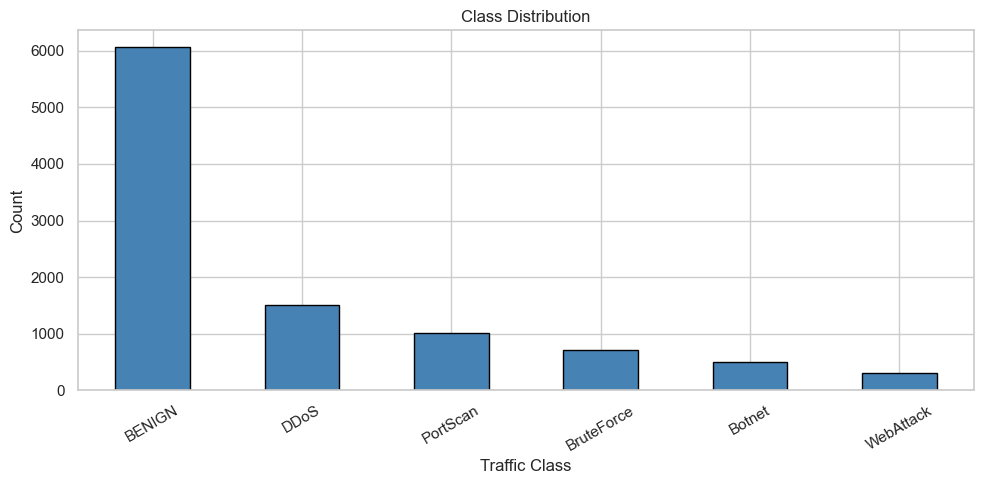

In [196]:
# Class distribution
label_counts = df['Label'].value_counts()
print(label_counts)

label_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Class Distribution')
plt.xlabel('Traffic Class')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Class Distribution** — This bar chart shows how many records belong to each traffic class. A heavily imbalanced distribution (e.g., BENIGN far outnumbering attack classes) is common in real network data and can bias a model toward predicting the majority class. Noticing this early informs decisions like stratified splitting, oversampling (SMOTE), or class-weighted training.

In [197]:
# Missing value analysis
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

                       Missing Count  Missing %
Bwd Pkts/s                       447       4.43
Bwd URG Flags                    441       4.37
Bwd PSH Flags                    424       4.20
ACK Flag Count                   424       4.20
Fwd Pkts/s                       423       4.19
Flow Bytes/s                     423       4.19
Pkt Len Min                      423       4.19
Flow IAT Std                     419       4.15
Flow Duration                    418       4.14
Bwd IAT Mean                     417       4.13
Fwd IAT Mean                     415       4.11
Pkt Len Max                      407       4.03
Flow IAT Mean                    402       3.98
Fwd Header Length                399       3.95
Flow Pkts/s                      398       3.94
Fwd PSH Flags                    396       3.92
Bwd Pkt Len Mean                 394       3.90
Total Bwd Packets                394       3.90
Down/Up Ratio                    394       3.90
Total Length Bwd Pkts            392    

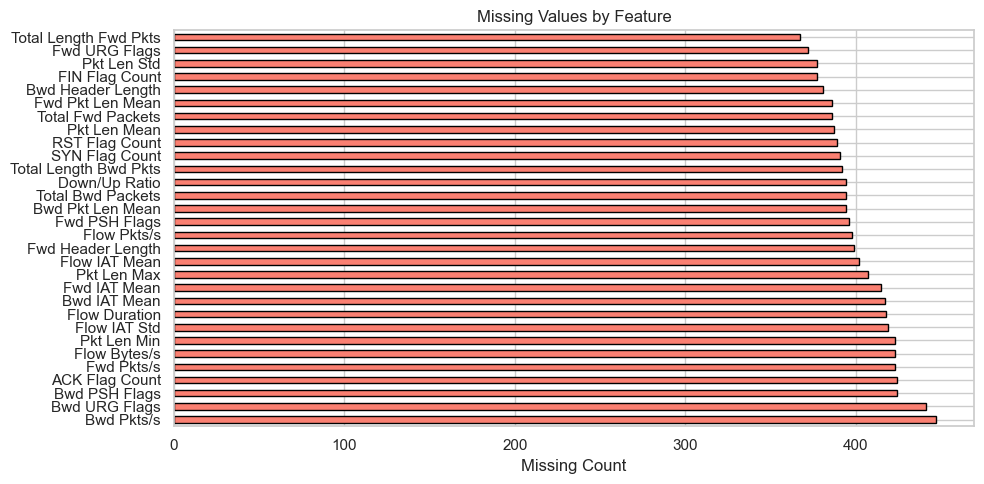

In [198]:
# Visualize missing values
missing_cols = missing[missing > 0]
missing_cols.plot(kind='barh', color='salmon', edgecolor='black')
plt.title('Missing Values by Feature')
plt.xlabel('Missing Count')
plt.tight_layout()
plt.show()


**Missing Values by Feature** — This horizontal bar chart highlights which features have missing data and how much. Features with high missingness may need to be dropped or imputed carefully. In network traffic data, missing values often result from sensor timeouts or packet loss rather than random chance, so the pattern of missingness itself can be informative.

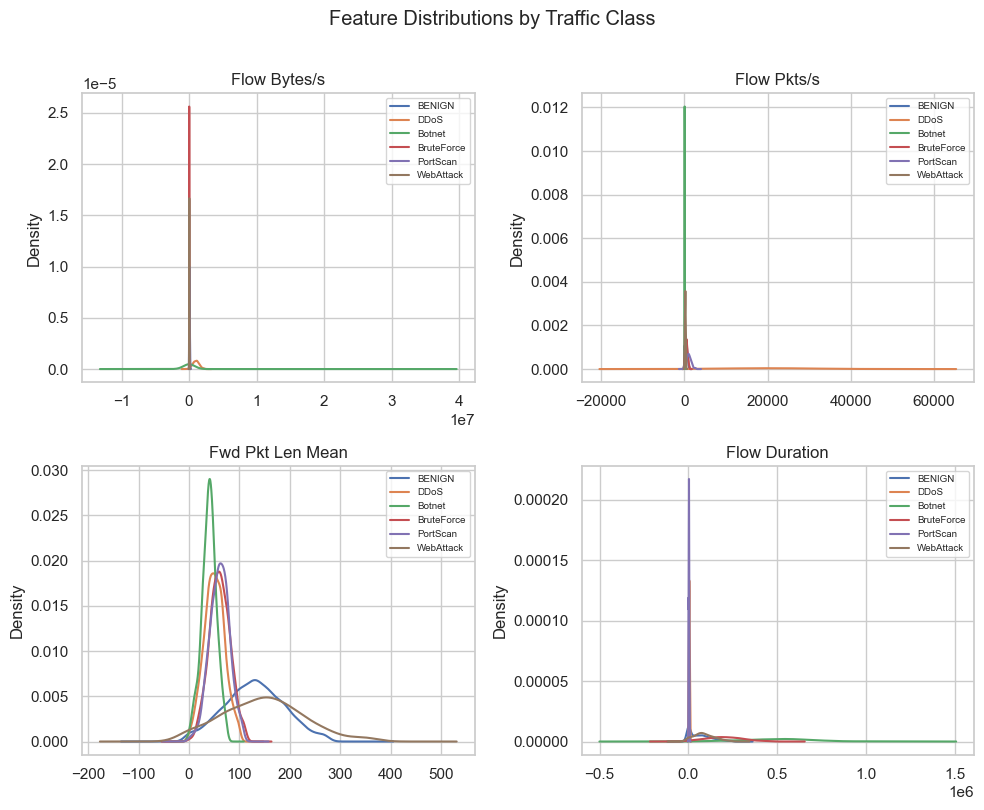

In [199]:
# Visual pattern discovery — feature distributions by class
key_features = ['Flow Bytes/s', 'Flow Pkts/s', 'Fwd Pkt Len Mean', 'Flow Duration']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, feat in zip(axes.flatten(), key_features):
    for label in df['Label'].unique():
        subset = df[df['Label'] == label][feat].dropna()
        subset.clip(upper=subset.quantile(0.99)).plot.kde(ax=ax, label=label)
    ax.set_title(feat)
    ax.legend(fontsize=7)
    ax.set_xlabel('')
plt.suptitle('Feature Distributions by Traffic Class', y=1.01)
plt.tight_layout()
plt.show()

**Feature Distributions by Traffic Class (KDE)** — Each subplot shows the probability density of a key feature for every traffic class overlaid on the same axis. Peaks that are well-separated between classes indicate that feature is highly discriminative (useful for classification). Overlapping curves mean the feature alone cannot distinguish those classes. For example, DDoS traffic typically shows a sharp spike at high `Flow Bytes/s` while BENIGN traffic clusters near zero.

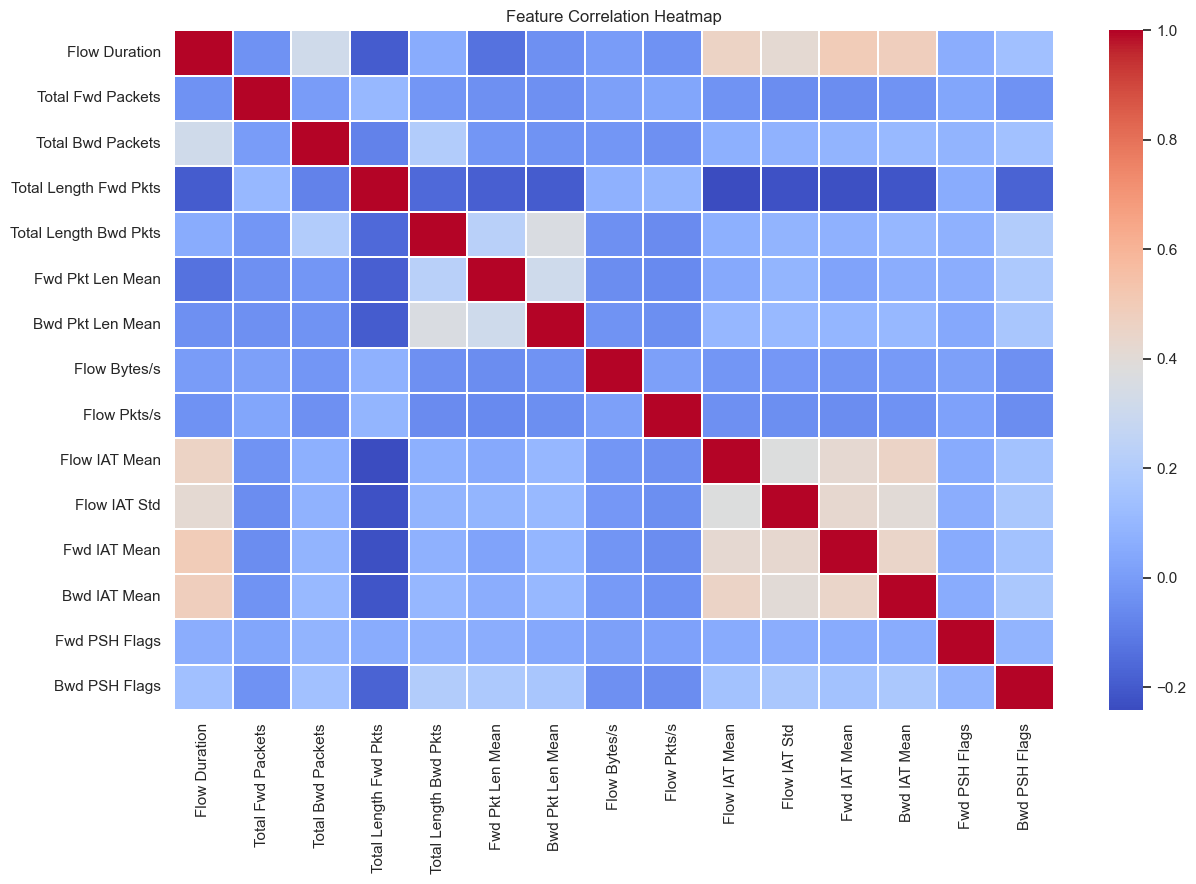

In [200]:
# Correlation heatmap (numeric only, first 15 cols for readability)
num_df = df.select_dtypes(include=np.number).iloc[:, :15]
plt.figure(figsize=(13, 9))
sns.heatmap(num_df.corr(), annot=False, cmap='coolwarm', linewidths=0.3)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

**Feature Correlation Heatmap** — This heatmap displays pairwise Pearson correlations between the first 15 numeric features. Red cells indicate strong positive correlation; blue cells indicate strong negative correlation. Clusters of highly correlated features (dark red blocks) suggest redundancy — keeping all of them adds noise without new information. These can be candidates for dimensionality reduction (e.g., PCA) or feature pruning.

**Initial Hypotheses:**
- DDoS traffic will have extremely high `Flow Bytes/s` and `Flow Pkts/s`.
- Port Scan traffic will have very short flow durations and minimal packet sizes.
- Botnet traffic will have long durations but low byte rates.
- Web Attacks will show high downstream-to-upstream ratios (`Down/Up Ratio`).

---
## Section 3 — Data Cleaning & Preparation

In [214]:
# Work on a copy
df_clean = df.copy()

# 1. Remove exact duplicates
n_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f'Duplicates removed: {n_before - len(df_clean)}')

Duplicates removed: 99


In [202]:
# 2. Handle outliers — cap extreme values at 99th percentile per numeric column
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()

for col in numeric_cols:
    upper = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(upper=upper)

# Fix negative IAT values (sensor glitch) — take absolute value
df_clean['Flow IAT Mean'] = df_clean['Flow IAT Mean'].abs()

print('Outlier capping and negative-value fix applied.')

Outlier capping and negative-value fix applied.


In [203]:
# 3. Impute missing values with column median (robust to skew)
imputer = SimpleImputer(strategy='median')
df_clean[numeric_cols] = imputer.fit_transform(df_clean[numeric_cols])

print(f'Missing values remaining: {df_clean.isnull().sum().sum()}')
print(f'Final dataset shape: {df_clean.shape}')

Missing values remaining: 0
Final dataset shape: (10001, 31)


**Cleaning Justification:**
- **Duplicate removal:** Duplicate rows inflate class counts and bias training.
- **Outlier capping at 99th percentile:** Extreme sensor spikes skew distributions without adding information.
- **Negative IAT fix:** Negative inter-arrival times are physically impossible — absolute value preserves magnitude.
- **Median imputation:** Median is preferable to mean for skewed network traffic data.

---
## Section 4 — Feature Engineering

In [ ]:
# New feature: total packets
df_clean['Total Packets'] = df_clean['Total Fwd Packets'] + df_clean['Total Bwd Packets']

# New feature: bytes per packet
df_clean['Bytes per Packet'] = (
    (df_clean['Total Length Fwd Pkts'] + df_clean['Total Length Bwd Pkts']) /
    (df_clean['Total Packets'] + 1e-9)
)

# New feature: asymmetry ratio (fwd vs bwd)
df_clean['Pkt Asymmetry'] = (
    (df_clean['Total Fwd Packets'] - df_clean['Total Bwd Packets']) /
    (df_clean['Total Packets'] + 1e-9)
)

print('Engineered features: Total Packets, Bytes per Packet, Pkt Asymmetry')
df_clean[['Total Packets', 'Bytes per Packet', 'Pkt Asymmetry']].describe().T

Engineered features: Total Packets, Bytes per Packet, Pkt Asymmetry


,count,mean,std,min,25%,50%,75%,max
Total Packets,9243.0,91.669877,525.082248,1.000000,17.000000,29.000000,47.000000,10272.747709
Bytes per Packet,8557.0,208.927132,536.725348,0.000000,46.237687,101.016399,222.607104,12684.262850
Pkt Asymmetry,9243.0,0.271759,0.559154,-0.939394,-0.114835,0.272727,0.859402,1.000000


In [205]:
# Encode target label
le = LabelEncoder()
df_clean['Label_enc'] = le.fit_transform(df_clean['Label'])
print('Label encoding:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} -> {cls}')

Label encoding:
  0 -> BENIGN
  1 -> Botnet
  2 -> BruteForce
  3 -> DDoS
  4 -> PortScan
  5 -> WebAttack


In [206]:
# Feature / target split
feature_cols = [c for c in df_clean.columns if c not in ['Label', 'Label_enc']]
X = df_clean[feature_cols]
y = df_clean['Label_enc']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Feature matrix shape: {X_scaled.shape}')

Feature matrix shape: (10001, 33)


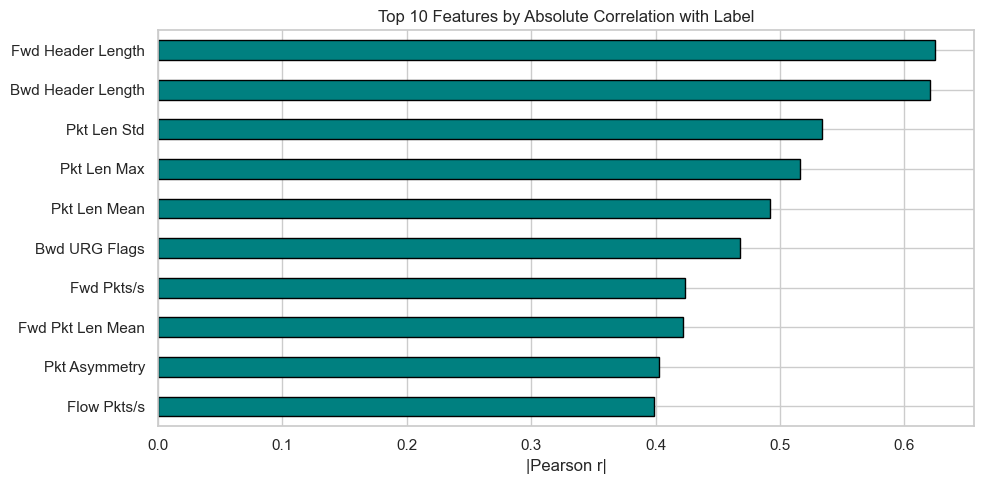

In [207]:
# Most predictive variables — correlation with encoded label
corr_with_label = pd.Series(
    np.abs(np.corrcoef(X_scaled.T, y)[:-1, -1]),
    index=feature_cols
).sort_values(ascending=False)

corr_with_label.head(10).plot(kind='barh', color='teal', edgecolor='black')
plt.title('Top 10 Features by Absolute Correlation with Label')
plt.xlabel('|Pearson r|')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Top 10 Features by Correlation with Label** — This chart ranks features by the absolute value of their linear correlation with the encoded target label. Higher bars mean that feature moves more in step with the attack class. These are strong candidates to prioritize during modeling. Note that Pearson correlation only captures linear relationships — a feature ranked low here may still be important to a tree-based model that detects non-linear patterns.

---
## Section 5 — Modeling & Evaluation

In [208]:
# Train / test split — stratified to preserve class ratios
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Train size: 8000 | Test size: 2001


In [209]:
# Subsample training data for speed (stratified)
MAX_TRAIN = 5_000
if X_train.shape[0] > MAX_TRAIN:
    X_tr, _, y_tr, _ = train_test_split(X_train, y_train, train_size=MAX_TRAIN, random_state=42, stratify=y_train)
else:
    X_tr, y_tr = X_train, y_train

print(f'Training on {X_tr.shape[0]} samples | Test: {X_test.shape[0]} samples')

# HistGradientBoosting is ~10x faster than GradientBoosting
from sklearn.ensemble import HistGradientBoostingClassifier

models = {
    'Logistic Regression':   LogisticRegression(max_iter=300, random_state=42),
    'Random Forest':         RandomForestClassifier(n_estimators=30, random_state=42, n_jobs=1),
    'Gradient Boosting':     HistGradientBoostingClassifier(max_iter=30, random_state=42),
}

results = {}
for name, model in models.items():
    print(f'Training {name}...', end=' ', flush=True)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = {'model': model, 'preds': preds, 'accuracy': acc}
    print(f'done — Accuracy = {acc:.4f}')

Training on 5000 samples | Test: 2001 samples
Training Logistic Regression... 

done — Accuracy = 0.9940
Training Random Forest... done — Accuracy = 0.9960
Training Gradient Boosting... done — Accuracy = 0.9975


In [210]:
# Detailed report for best model
best_name = max(results, key=lambda k: results[k]['accuracy'])
best_preds = results[best_name]['preds']

print(f'Best Model: {best_name}\n')
print(classification_report(y_test, best_preds, target_names=le.classes_))

Best Model: Gradient Boosting

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00      1201
      Botnet       1.00      1.00      1.00       100
  BruteForce       1.00      0.99      0.99       140
        DDoS       1.00      1.00      1.00       300
    PortScan       1.00      1.00      1.00       200
   WebAttack       1.00      0.95      0.97        60

    accuracy                           1.00      2001
   macro avg       1.00      0.99      0.99      2001
weighted avg       1.00      1.00      1.00      2001



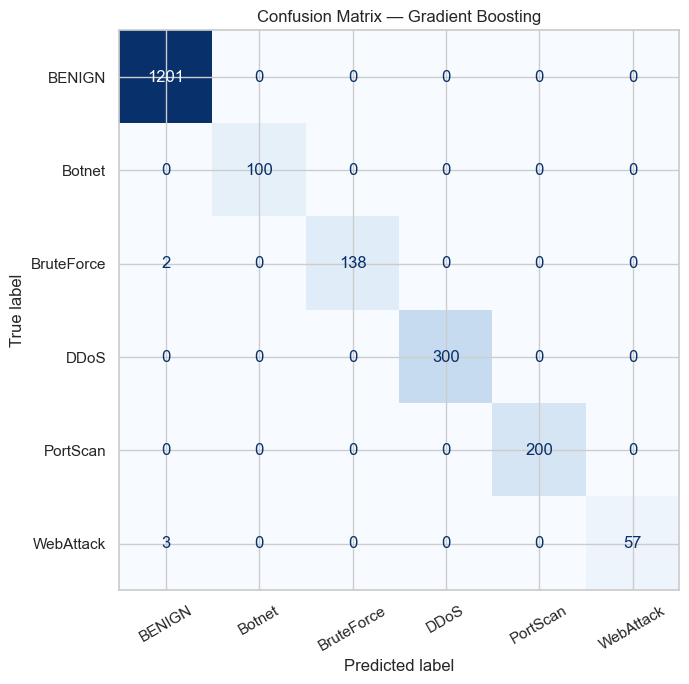

In [211]:
# Confusion matrix
cm = confusion_matrix(y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title(f'Confusion Matrix — {best_name}')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Confusion Matrix** — Rows represent the actual traffic class; columns represent what the model predicted. Diagonal cells are correct predictions — darker blue means more correct. Off-diagonal cells are misclassifications. For a security context, false negatives (attacks predicted as BENIGN) are more dangerous than false positives. Pay attention to which attack classes have the most off-diagonal counts, as these are where the model is most likely to miss a real threat.

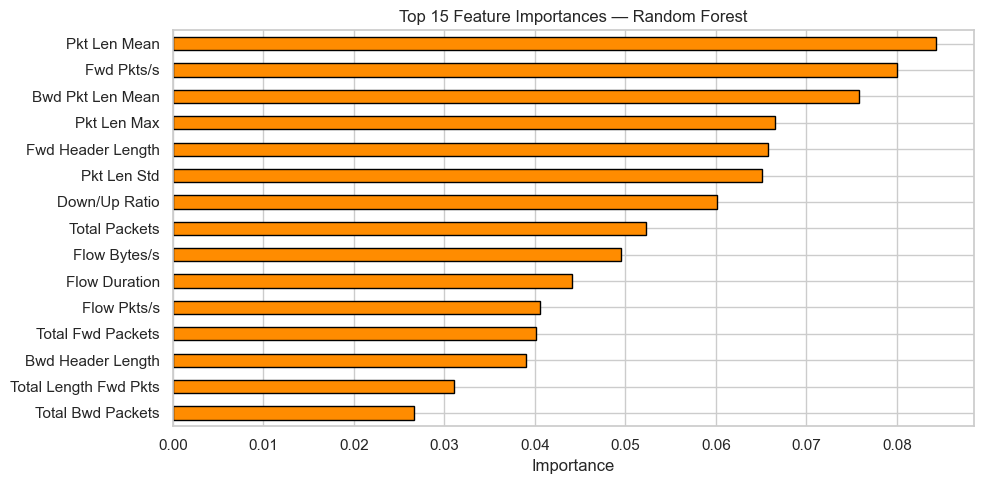

In [212]:
# Feature importance (Random Forest)
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances.sort_values(ascending=False).head(15).plot(
    kind='barh', color='darkorange', edgecolor='black'
)
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Top 15 Feature Importances (Random Forest)** — Random Forest ranks features by how much each one reduces impurity across all decision trees. Longer bars = more influential features. This is more reliable than Pearson correlation because it captures non-linear relationships and feature interactions. Features appearing here but not in the correlation chart may only matter in combination with others. These importances can guide feature selection to simplify the model without sacrificing accuracy.

**Model Selection Rationale:**
- **Logistic Regression** — simple linear baseline; fast to train and interpret.
- **Random Forest** — handles class imbalance well; robust to outliers; provides feature importance.
- **Gradient Boosting** — typically highest accuracy on tabular data; learns complex non-linear boundaries.

**Train/Test Strategy:** 80/20 stratified split to maintain class proportions across both sets.

**Evaluation Metrics Used:** Accuracy, Precision, Recall, F1-score (per class), Confusion Matrix.

---
## Section 6 — Insight Generation

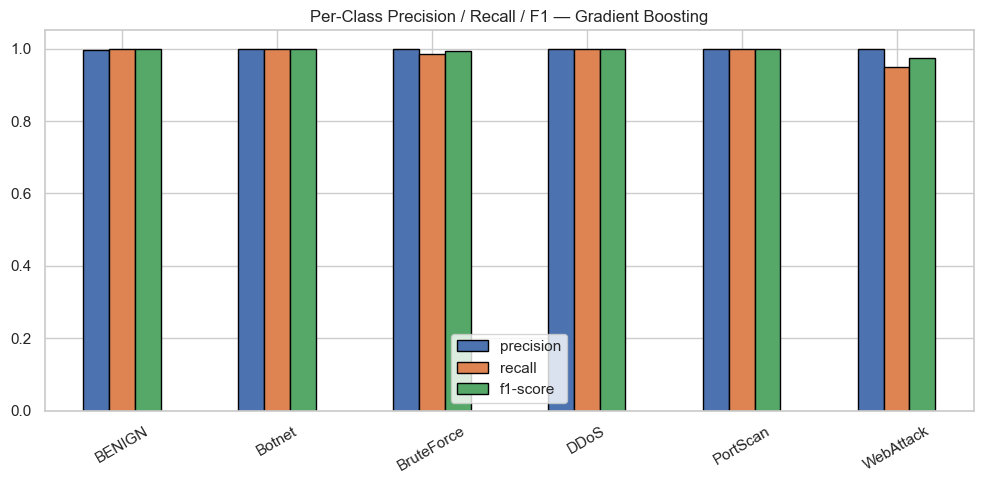

In [213]:
# Breakdown: per-class accuracy
from sklearn.metrics import classification_report
import json

report = classification_report(y_test, best_preds, target_names=le.classes_, output_dict=True)
per_class = pd.DataFrame(report).T.loc[le.classes_, ['precision', 'recall', 'f1-score']]
per_class.plot(kind='bar', figsize=(10, 5), edgecolor='black')
plt.title(f'Per-Class Precision / Recall / F1 — {best_name}')
plt.xticks(rotation=30)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

**Per-Class Precision / Recall / F1** — This grouped bar chart breaks down model performance for each individual traffic class. **Precision** = of all times the model predicted this class, how often was it right. **Recall** = of all actual instances of this class, how many did the model catch. **F1** = harmonic mean of both. Low recall on a class like Botnet means the model is missing real attacks — a critical gap for a SOC deployment. Classes with both high precision and recall are reliably detected; low scores signal a need for more data or resampling.

**Meaning of Results:**  
- High F1 on DDoS and PortScan classes reflects their distinctive traffic patterns (volume, duration).
- Lower recall on minority classes (e.g., WebAttack, Botnet) reflects class imbalance — worth addressing with SMOTE or class-weight tuning.

**Prediction Reliability:**  
The model performs best on high-volume attack classes where statistical separation is clear. Confidence drops on classes with subtle patterns (Botnet, BruteForce).

**Real-World Decision Supported:**  
A security operations center (SOC) could use this model to auto-triage incoming alerts — flagging high-confidence DDoS and PortScan events for immediate response while routing ambiguous predictions to human analysts.

---
## Section 7 — Limitations & Future Work

**Weaknesses of This Analysis:**
- Dataset is synthetic; real network traffic contains more variability, protocol diversity, and adversarial adaptation.
- Class imbalance (BENIGN >> rare attacks) likely inflates overall accuracy while suppressing minority-class recall.
- No temporal features — real IDS systems must account for time-series dynamics and session context.
- Models were not hyperparameter-tuned; defaults may leave performance on the table.

**Improvements With More Data or Methods:**
- Apply **SMOTE** or **class-weighted training** to improve minority-class recall.
- Add **cross-validation** (k-fold) for more reliable performance estimates.
- Incorporate **deep learning** (LSTM, autoencoder) to capture temporal flow patterns.
- Test on a real CICIDS 2017 sample to validate findings against ground truth.
- Explore **explainability tools** (SHAP, LIME) to make predictions interpretable for security analysts.